# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('../car_price_dataset.csv')
print(df.head())

   Car_ID    Brand  Model_Year  Engine_Size Fuel_Type Transmission  Mileage  \
0       1     Ford        2023          1.2    Hybrid       Manual   180635   
1       2  Hyundai        2018          3.2  Electric       Manual    35628   
2       3      BMW        2008          2.2    Diesel       Manual    74672   
3       4  Hyundai        2017          2.2    Petrol    Automatic    51246   
4       5  Hyundai        2012          2.4  Electric       Manual   147233   

   Doors  Owner_Count  Horsepower     Price  
0      4            3          82  34309.25  
1      2            4         259  55153.60  
2      3            2         333  41894.40  
3      4            4         381  54046.70  
4      3            4         290  38010.35  


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
print("--- Info Dataset ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   object 
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   object 
 5   Transmission  2000 non-null   object 
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), object(3)
memory usage: 172.0+ KB
None

--- Missing Values ---
Car_ID          0
Brand           0
Model_Year      0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Horsepower      0
Price           0
dtype: int64


In [11]:
duplicate_count = df.duplicated().sum()
print(f"Jumlah baris duplikat: {duplicate_count}")

print("\n--- Statistik Deskriptif ---")
print(df.describe())

Jumlah baris duplikat: 0

--- Statistik Deskriptif ---
            Car_ID   Model_Year  Engine_Size        Mileage        Doors  \
count  2000.000000  2000.000000  2000.000000    2000.000000  2000.000000   
mean   1000.500000  2013.963000     2.967550  100736.956500     2.988000   
std     577.494589     5.508248     1.146926   56002.915221     0.818041   
min       1.000000  2005.000000     1.000000    5036.000000     2.000000   
25%     500.750000  2009.000000     2.000000   52365.500000     2.000000   
50%    1000.500000  2014.000000     2.900000  100590.500000     3.000000   
75%    1500.250000  2019.000000     4.000000  148024.500000     4.000000   
max    2000.000000  2023.000000     5.000000  199904.000000     4.000000   

       Owner_Count  Horsepower         Price  
count  2000.000000  2000.00000   2000.000000  
mean      2.532500   235.70950  46169.507675  
std       1.125423    95.59811   9211.685713  
min       1.000000    70.00000  18911.550000  
25%       2.000000   154.

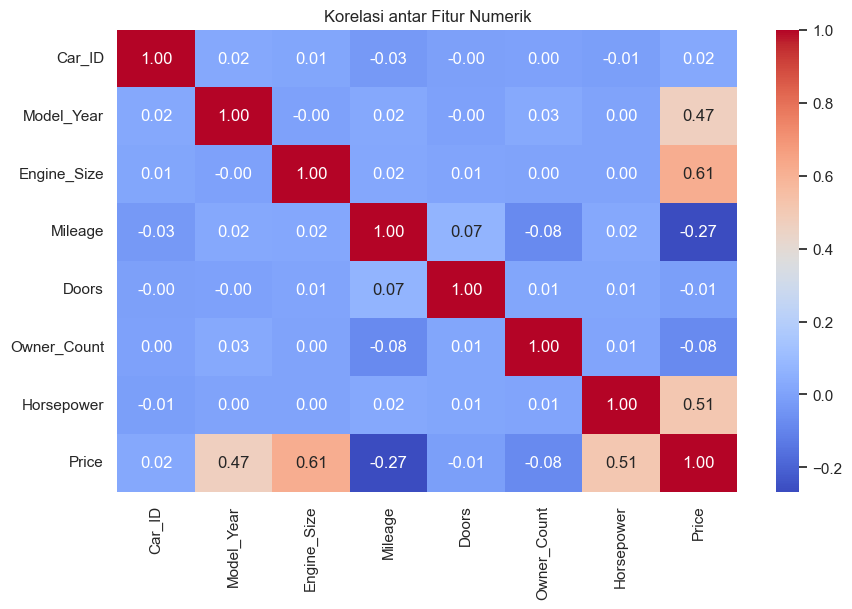

In [9]:
plt.figure(figsize=(10, 6))
numeric_data = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi antar Fitur Numerik")
plt.show()

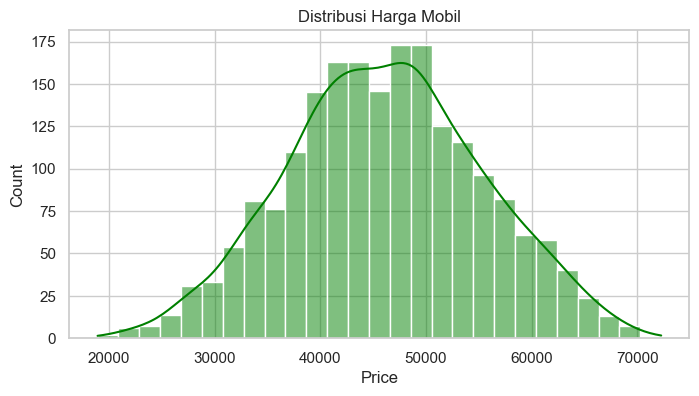

In [10]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='green')
plt.title("Distribusi Harga Mobil")
plt.show()

In [12]:
def count_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return len(outliers)

# Cek outliers untuk fitur numerik utama
cols_to_check = ['Price', 'Mileage', 'Horsepower', 'Engine_Size']
for col in cols_to_check:
    print(f"Jumlah outlier di {col}: {count_outliers(df, col)}")

Jumlah outlier di Price: 2
Jumlah outlier di Mileage: 0
Jumlah outlier di Horsepower: 0
Jumlah outlier di Engine_Size: 0


In [13]:
cat_cols = ['Brand', 'Fuel_Type', 'Transmission']
for col in cat_cols:
    print(f"\nKategori unik di {col}:")
    print(df[col].value_counts())


Kategori unik di Brand:
Brand
Toyota     352
Hyundai    337
Tesla      330
Honda      329
Ford       326
BMW        326
Name: count, dtype: int64

Kategori unik di Fuel_Type:
Fuel_Type
Diesel      537
Petrol      511
Electric    484
Hybrid      468
Name: count, dtype: int64

Kategori unik di Transmission:
Transmission
Automatic    1018
Manual        982
Name: count, dtype: int64


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [15]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Price'] >= Q1 - 1.5 * IQR) & (df['Price'] <= Q3 + 1.5 * IQR)]

In [16]:
df = df.drop(columns=['Car_ID'])

In [18]:
df['Car_Age'] = 2026 - df['Model_Year']
df['Mileage_per_Year'] = df['Mileage'] / (df['Car_Age'] + 1) # +1 agar tidak error pembagian nol

In [19]:
bins = [2000, 2010, 2015, 2020, 2026]
labels = ['Vintage', 'Old', 'Modern', 'New']
df['Year_Category'] = pd.cut(df['Model_Year'], bins=bins, labels=labels)

In [20]:
df = pd.get_dummies(df, columns=['Fuel_Type', 'Transmission', 'Year_Category', 'Brand'], drop_first=True)

In [21]:
# 6. Standarisasi Fitur Numerik
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
num_cols = ['Mileage', 'Horsepower', 'Engine_Size', 'Car_Age', 'Mileage_per_Year']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [22]:
# 7. Simpan hasil ke CSV
df.to_csv('car_price_dataset_preprocessing.csv', index=False)

In [23]:
print(df.head())

   Model_Year  Engine_Size   Mileage  Doors  Owner_Count  Horsepower  \
0        2023    -1.542347  1.427446      4            3   -1.609428   
1        2018     0.202816 -1.163597      2            4    0.243911   
2        2008    -0.669765 -0.465944      3            2    1.018753   
3        2017    -0.669765 -0.884529      4            4    1.521353   
4        2012    -0.495249  0.830605      3            4    0.568507   

      Price   Car_Age  Mileage_per_Year  Fuel_Type_Electric  ...  \
0  34309.25 -1.640831          4.142625               False  ...   
1  55153.60 -0.732843         -0.699605                True  ...   
2  41894.40  1.083132         -0.702962               False  ...   
3  54046.70 -0.551246         -0.562574               False  ...   
4  38010.35  0.356742         -0.011250                True  ...   

   Fuel_Type_Petrol  Transmission_Manual  Year_Category_Old  \
0             False                 True              False   
1             False             